## Summary
- **앙상블 모형은 일별 매출을 비교적 정확하게 예측한다.**  
  (2020~2023 학습 데이터 기반, 2024년 1월 예측 기준)
- **Recency Weighting** (연도별 가중치 0.1→0.4)을 적용해 최근 패턴에 학습을 집중시켰다.
- **LightGBM** 모델이 최종 테스트(2024년 1월)에서 MSE 17,749, 오차율 -0.92%로 가장 우수한 성능을 기록했다.
- CV(Expanding Window) 평균 MSE 기준으로도 **LightGBM**(12,972)이 가장 낮았다.
- 매출 예측에 **요일(dayofweek)** 과 **일(day)** 이 가장 중요한 변수로 나타났다.

## 0. 프로젝트 개요

- **문제 인식**: 신용카드 월별 매출목표만 존재하고, 구체적인 일별 매출 예측이 부족한 상황
- **솔루션 목표**: 머신러닝을 사용하여 보다 정확한 신용카드 일별 매출을 예측하고자 함
- **예상 결과**: 일별 매출 예측을 통해 마케팅 캠페인 기획, 재무 계획 등에 활용 가능

미래 매출 예측은 마케팅 캠페인 기획, 재무 계획 설립 등 다양한 사업 영역에서 활용한다. 이 프로젝트는 신용카드 일별 매출 데이터를 기반으로 미래 매출을 예측하고자 한다. 

실제 업무 환경에서도 체계적인 매출 예측방법론이 존재하지 않고 담당자의 경험과 재량에 의존하는 경우도 많다. 체계적인 예측방법론 정립을 위해 **RandomForest**, **XGBoost**, **LightGBM** 3가지 머신러닝 모델을 사용하여 예측 성능을 비교하였다.

In [1]:
# %% 0. Environment Settings
import platform
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.style.use('ggplot')

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
else:
    plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)

## 1. 데이터 로딩

### 실제 환경에서의 데이터 로딩
실제 업무환경에서는 DW에서 데이터를 직접 추출하여 사용하였다. RDBMS 환경에서는 Oracle SQL을, Hadoop 환경에서는 Impala SQL을 사용하여 데이터를 추출한다. 보안과 규제로 인해 실제 데이터를 사용할 수 없으므로, 공개 데이터를 활용하여 Replication을 진행한다.

### Replication 데이터 출처
데이터는 **금융데이터거래소**에서 제공하는 **NH농협카드 일자별 소비현황_서울** 데이터셋을 사용한다. 데이터는 csv 파일 형태로 월별로 제공되며, 각 파일명은 '_YYYYMM' 형식으로 끝난다. 데이터 오너십을 가지고 있지 않아 리포지토리에는 제외하지만 아래 공개 데이터 링크에서 직접 다운받을 수 있다.

- **데이터**: [금융데이터거래소 - NH농협카드 일자별 소비현황](https://www.findatamall.or.kr/market/dataProdList?prodCd=GENERAL&menuNo=28)
- 훈련 데이터: 2020.01 ~ 2023.12 서울 지역 일자별 소비현황
- 검증 데이터: 2024.01 서울 지역 일자별 소비현황
- 주요 컬럼은 카드 사용 금액과 건수, 승인 일자 등의 정보를 포함한다.


In [2]:
# %% 1. LOAD THE DATA
# Data Source: KDX Data - [NH농협카드] 일자별 소비현황_서울
bas_ym = pd.date_range(start='20200101', end='20240131', freq='MS').strftime('%Y%m').tolist()

df = pd.DataFrame()

for i, var in enumerate(bas_ym):
    data_path = f'data/[NH농협카드] 일자별 소비현황_서울_{var}.csv'
    
    # Read the data with available encodings
    encodings = ['utf-8-sig', 'euc-kr', 'cp949']
    for encoding in encodings:
        try:
            tmp_df = pd.read_csv(data_path, encoding=encoding)
            break
        except UnicodeDecodeError:
            continue
    else:
        raise ValueError(f"Failed to read {data_path} with available encodings.")
    
    df = pd.concat([df, tmp_df], axis=0)
    
print(df.shape)
print(df.head())

(1492, 8)
   시도      승인일자  이용건수_전체  이용금액_전체  이용건수_개인  이용금액_개인  이용건수_법인  이용금액_법인
0  서울  20200101   1827.0  48116.0   1770.0  45654.0     57.0   2462.0
1  서울  20200102   2071.0  78042.0   1932.0  66654.0    139.0  11388.0
2  서울  20200103   2140.0  77224.0   1995.0  64302.0    144.0  12922.0
3  서울  20200104   1969.0  55070.0   1891.0  51702.0     78.0   3369.0
4  서울  20200105   1711.0  46359.0   1649.0  43796.0     62.0   2563.0


## 2. 데이터 전처리

### 2.1. 데이터 타입 변환
승인일자를 `datetime64` 타입으로 변환하고 금액 변수들의 단위를 분석에 용이하게 변경한다. (백만원 -> 억원)

### 2.2. 파생 변수 생성
연도(`year`), 월(`month`), 일(`day`), 요일(`dayofweek`), 주말 여부(`weekend`) 등의 파생 변수를 생성하여 모델에 활용할 수 있도록 한다. 금액의 평균을 나타내는 변수들도 분석 참고용으로 생성한다 (`avg_sales`, `avg_sales_psn`, `avg_sales_cor`).

### 2.3. 범주형 변수 변환
요일(`dayname`) 변수를 순서형 변수로 변환하여 모델에 활용한다. 요일은 명목형 범주에 해당하지만, 시각화 등을 위해서 순서형으로 변환하는 것이 편리하다.

### 2.4. 데이터 분할
2020~2023 데이터를 훈련 데이터로 사용하여 2024년 1월 매출 예측을 수행할 것이다. 과거 4년 데이터를 학습하여 1개월 뒤 매출을 예측함으로써 모델의 일반화 성능을 확인한다.


In [3]:
# %% 2. DATA PREPROCESSING
# Type Conversion (int64 -> datetime64)
df['date'] = pd.to_datetime(df['승인일자'], format='%Y%m%d')

# Decimal Point Handling
df['이용금액_전체_억원'] = df['이용금액_전체'] / 100
df['이용금액_개인_억원'] = df['이용금액_개인'] / 100
df['이용금액_법인_억원'] = df['이용금액_법인'] / 100

# Derived Variables
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek

# Nominal to Ordinal Variable
df['dayname'] = pd.Categorical(df['date'].dt.day_name(), 
                               categories=['Monday', 'Tuesday', 'Wednesday','Thursday', 'Friday', 'Saturday', 'Sunday'],
                               ordered=True)

# Add weekend variable
df['weekend'] = df['dayname'].isin(['Saturday', 'Sunday'])

# Nullity Check
print(df.isna().sum())

# Train-Test Split
df_train = df[df['year'] != 2024]
df_test = df[df['year'] == 2024]

print(df_train.shape, df_test.shape)

# Reset Index
df.reset_index(drop=True, inplace=True)

시도            0
승인일자          0
이용건수_전체       0
이용금액_전체       0
이용건수_개인       0
이용금액_개인       0
이용건수_법인       0
이용금액_법인       0
date          0
이용금액_전체_억원    0
이용금액_개인_억원    0
이용금액_법인_억원    0
year          0
month         0
day           0
dayofweek     0
dayname       0
weekend       0
dtype: int64
(1461, 18) (31, 18)


## 3. 데이터 탐색적 분석 (EDA)

### 3.1. 결측치 확인
- 데이터에서 결측치를 시각적으로 확인하고 적절히 처리한다.
- `sns.heatmap`을 사용하면 결측치를 시각화할 수 있지만 대규모 데이터의 경우 시각적으로 확인하기 힘드므로 `.sum` 등으로도 확인한다.

### 3.2. 변수 간 상관관계 확인

- 상관 행렬을 통해 변수들 간의 상관관계를 확인하고, 다중공선성 문제를 방지하기 위해 일부 변수를 제거하거나 변형할 수 있다.
- 본 분석에서는 주요 독립변수인 연도(`year`), 월(`month`), 일(`day`), 요일(`dayofweek`) 간 상관성이 낮아 변수 제거는 시행하지 않았다. 

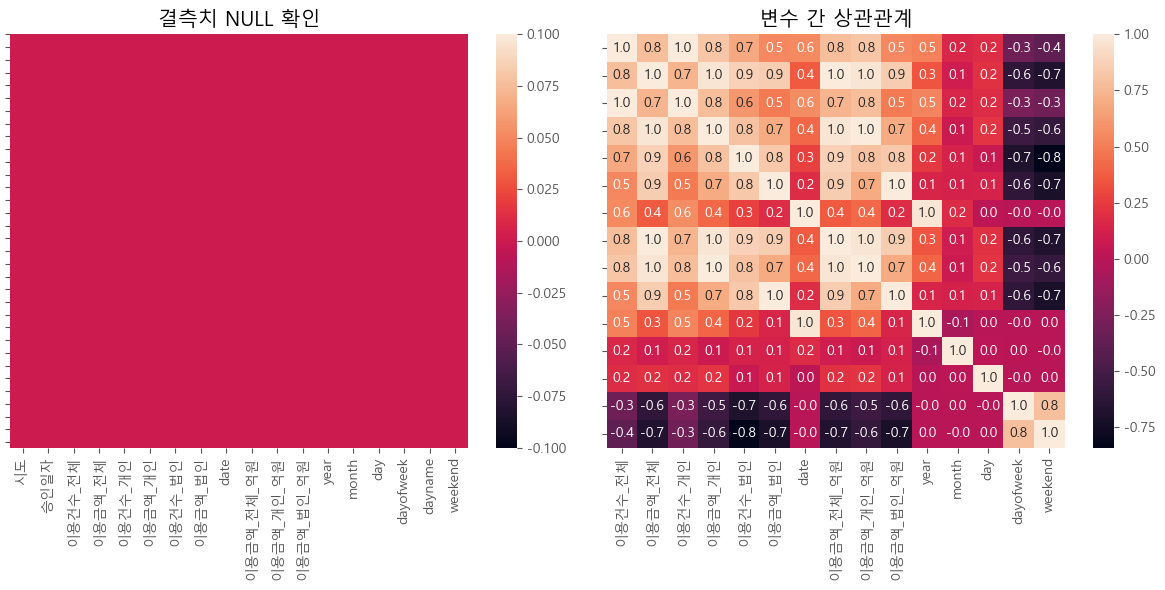

In [4]:
# %% 3. EDA
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6))

# 3-1. Null Handling
sns.heatmap(df.isna(), ax=axes[0])
axes[0].set_title('결측치 NULL 확인')
axes[0].set_yticklabels([])

# 3-2. Correlation Matrix (Multicolinearity Check)
corr_mat = df.drop(['시도', '승인일자', 'dayname'], axis=1).corr()

sns.heatmap(corr_mat, annot=True, fmt='.1f', ax=axes[1])
axes[1].set_yticklabels([])

axes[1].set_title('변수 간 상관관계')
plt.tight_layout()
plt.savefig("images/fig2.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.3. 이상치 탐지/제거

주요 변수들에 대해 선형 그래프와 박스플롯을 사용하여 이상치를 탐지한다.

- 일반적으로는 IQR, 2표준편차 방식을 사용해서 이상치를 탐지하고 제외한다.
- **IQR을 벗어난다고 무작정 제외하지 않는다.** 예를 들어 법인 매출에는 유독 튀는 몇몇 날짜가 존재한다. 데이터 오류(이상치)일 수도 있지만 실제 주요 실적일 수 있다. 
- 법인 거래는 거래빈도는 작고 거래금액은 크다. 기계적으로 이상치로 판단해 해당 값을 제외할 경우 실적을 과소추정할 수 있다.
- raw data에 접근 가능한 상황이라면 가장 먼저 데이터를 의심하고 raw date를 확인한다. 만약 문제가 없거나 접근이 불가능한 상태라면 각 업무 담당자에게 확인하는 것이 좋다.

이러한 문제로 본 분석에서는 이상치 제거를 수행하지 않고 이후 분석을 진행한다.

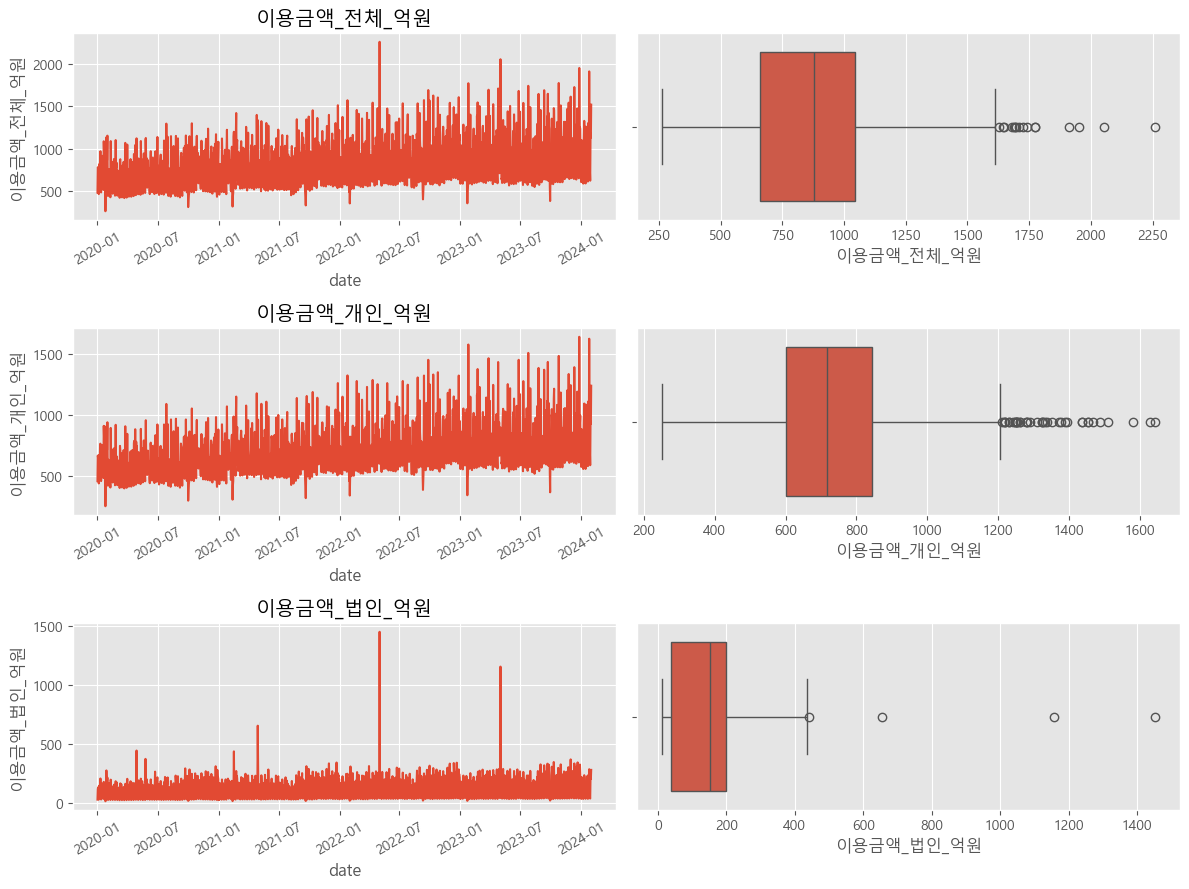

In [5]:
# 3-3. Outlier Detection
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12,9))

variables = ['이용금액_전체_억원', '이용금액_개인_억원', '이용금액_법인_억원']
 
for i, vars in enumerate(variables):
    sns.lineplot(data=df, x='date', y=vars,
                ax=axes[i%3][0])
    sns.boxplot(data=df, x=vars,
                ax=axes[i%3][1])
    axes[i%3][0].set_title(vars)
    axes[i%3][0].tick_params(axis='x', rotation=30)


plt.tight_layout()
fig.suptitle('')
plt.savefig("images/fig3.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.4. 매출 분석

- 매출 데이터는 요일별로 시각화하여 소비 패턴을 분석한다. 이를 통해 매출이 특정 요일에 따라 차이를 보인다는 인사이트를 도출한다.

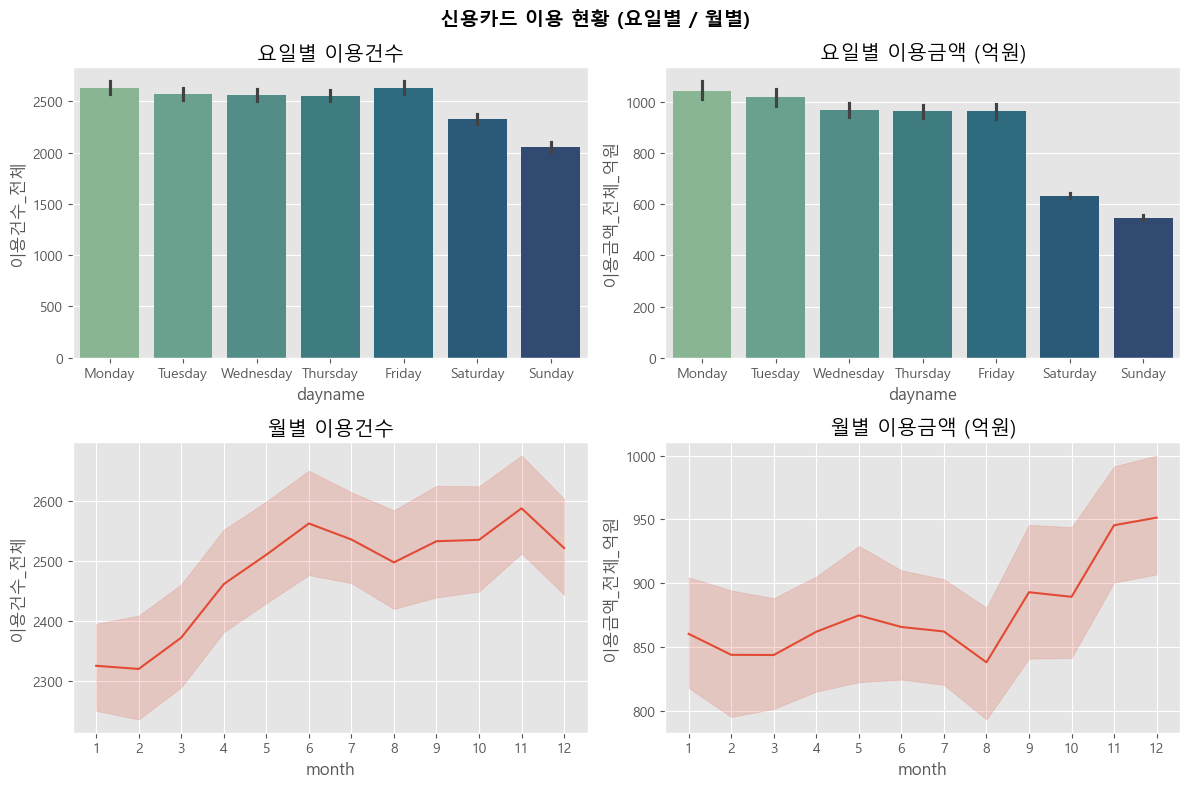

In [6]:
# 3-4. Sales by Day & Month
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,8))

# Row 1: 요일별
sns.barplot(data=df, x='dayname', y='이용건수_전체',
            hue='dayname', palette='crest', legend=False, ax=axes[0][0])
sns.barplot(data=df, x='dayname', y='이용금액_전체_억원',
            hue='dayname', palette='crest', legend=False, ax=axes[0][1])
axes[0][0].set_title('요일별 이용건수')
axes[0][1].set_title('요일별 이용금액 (억원)')

# Row 2: 월별
sns.lineplot(data=df, x='month', y='이용건수_전체', ax=axes[1][0])
sns.lineplot(data=df, x='month', y='이용금액_전체_억원', ax=axes[1][1])
axes[1][0].set_title('월별 이용건수')
axes[1][1].set_title('월별 이용금액 (억원)')
axes[1][0].set_xticks(range(1,13))
axes[1][1].set_xticks(range(1,13))

fig.suptitle('신용카드 이용 현황 (요일별 / 월별)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("images/fig4.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. 모델링

### 4.1. 회귀 모델 설정

- 모델링을 위해 **RandomForest**, **XGBoost**, **LightGBM**을 사용하여 예측을 수행한다.
- 각 모델은 카드 사용 금액(`이용금액_개인_억원`)을 종속 변수로 설정하고, 연도, 월, 요일 등의 변수를 독립 변수로 설정하여 학습한다.
- **Time Window Expanding Cross Validation**으로 모델 성능을 평가하고, 2020~2023 전체 데이터로 최종 모델을 학습한다.
- **Recency Weighting**: 최근 데이터가 2024년 소비 패턴을 더 잘 대표한다는 가정 하에, 연도별 `sample_weight`를 부여한다. 2020=0.1, 2021=0.2, 2022=0.3, 2023=0.4로 설정하여 최근 연도에 4배 높은 학습 영향력을 준다.

In [7]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 4-1. Time Window Expanding Cross Validation
ind_vars = ['승인일자', 'year', 'month', 'day', 'dayofweek']
dep_var  = '이용금액_개인_억원'

WEIGHT_MAP = {2020: 0.1, 2021: 0.2, 2022: 0.3, 2023: 0.4}

df_cv_data = df[df["year"] != 2024].copy()
periods = sorted(df_cv_data['date'].dt.to_period('M').unique())

cv_results = []

for i in range(1, len(periods)):
    train_mask = df_cv_data['date'].dt.to_period('M').isin(periods[:i])
    test_mask  = df_cv_data['date'].dt.to_period('M') == periods[i]

    X_tr = df_cv_data[train_mask][ind_vars]
    y_tr = df_cv_data[train_mask][dep_var]
    X_te = df_cv_data[test_mask][ind_vars]
    y_te = df_cv_data[test_mask][dep_var]
    w_tr = df_cv_data[train_mask]['year'].map(WEIGHT_MAP).values

    m_rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        max_features='sqrt',
        min_samples_leaf=3,
        random_state=42
    )
    m_xgb = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        reg_alpha=0.05,
        random_state=42
    )
    m_lgbm = LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=1.0,
        min_child_samples=20,
        reg_alpha=0,
        random_state=42,
        verbose=-1
    )

    m_rf.fit(X_tr, y_tr, sample_weight=w_tr)
    m_xgb.fit(X_tr, y_tr, sample_weight=w_tr)
    m_lgbm.fit(X_tr, y_tr, sample_weight=w_tr)

    pred_rf   = m_rf.predict(X_te)
    pred_xgb  = m_xgb.predict(X_te)
    pred_lgbm = m_lgbm.predict(X_te)

    cv_results.append({
        'test_period': str(periods[i]),
        'train_months': i,
        'mse_rf':   mean_squared_error(y_te, pred_rf),
        'mse_xgb':  mean_squared_error(y_te, pred_xgb),
        'mse_lgbm': mean_squared_error(y_te, pred_lgbm),
        'mae_rf':   mean_absolute_error(y_te, pred_rf),
        'mae_xgb':  mean_absolute_error(y_te, pred_xgb),
        'mae_lgbm': mean_absolute_error(y_te, pred_lgbm),
    })

df_cv = pd.DataFrame(cv_results)
print(df_cv[['test_period', 'train_months',
             'mse_rf', 'mse_xgb', 'mse_lgbm',
             'mae_rf', 'mae_xgb', 'mae_lgbm']].to_string(index=False))


test_period  train_months       mse_rf      mse_xgb     mse_lgbm     mae_rf    mae_xgb   mae_lgbm
    2020-02             1  7517.799963 15552.334907 15558.221680  64.293311  93.706404  93.736818
    2020-03             2  6612.389307 16855.796110 10018.501915  68.901302  99.628978  88.491730
    2020-04             3  6381.917253 11529.501958  6155.951673  60.569132  82.930479  61.769894
    2020-05             4  5825.996446  7998.566379  6593.040364  52.316067  67.096226  58.888579
    2020-06             5  3870.060347  3537.496577  2950.211704  48.853554  46.779607  42.457037
    2020-07             6  9051.154735  8003.211727  7388.478796  62.389462  61.539141  52.818119
    2020-08             7 12031.260646  7452.186269  7581.893073  95.321680  65.638217  62.477228
    2020-09             8  6370.456062  5609.021267  5684.261831  57.593430  48.248270  48.642954
    2020-10             9 15499.356186 14290.716884 14538.263228  83.727970  79.877106  76.414383
    2020-11         

### 4.2. 최종 모델 학습
- CV와 동일한 하이퍼파라미터와 **Recency Weighting**을 적용해 **전체 훈련 데이터(2020~2023)** 로 최종 모델을 학습한다.
- **RandomForestRegressor**는 최종 학습 시 `n_estimators=1000`으로 높여 정확도를 최대화한다.
- **XGBRegressor**와 **LGBMRegressor**는 `n_estimators=1000`으로 설정하여 CV 대비 더 충분히 학습한다.
- 가중치는 CV와 동일하게 `WEIGHT_MAP`을 재사용한다.

In [8]:
# 4-2. 전체 훈련 데이터로 최종 모델 학습
X_train = df_cv_data[ind_vars]
y_train = df_cv_data[dep_var]
w_train = df_cv_data['year'].map(WEIGHT_MAP).values

model_rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=5,
    max_features='sqrt',
    min_samples_leaf=3,
    random_state=42
)
model_xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.05,
    random_state=42
)
model_lgbm = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=1.0,
    min_child_samples=20,
    reg_alpha=0,
    random_state=42,
    verbose=-1
)

model_rf.fit(X_train, y_train, sample_weight=w_train)
model_xgb.fit(X_train, y_train, sample_weight=w_train)
model_lgbm.fit(X_train, y_train, sample_weight=w_train)


LGBMRegressor(learning_rate=0.05, max_depth=5, n_estimators=1000,
              random_state=42, reg_alpha=0, subsample=0.8, verbose=-1)

### 4.3. 모델 성능 평가 (Time Window Expanding CV)

- **Time Window Expanding Cross Validation**으로 47개 fold를 순차적으로 평가했다.
- 각 fold에서 누적된 과거 월 데이터를 학습하고, 그 다음 달을 테스트하는 방식으로 진행했다.
- **MSE (Mean Squared Error)** 기준 평균 성능과 fold별 MSE 추이를 아래에서 확인한다.
- CV 평균 MSE 기준으로는 **LightGBM**이 가장 우수하며, **RandomForest**가 최종 테스트에서 가장 낮은 오차를 기록한다.

[ CV 평균 성능 ]
모델                    MSE       MAE
────────────────────────────────────
RandomForest     14840.53     79.69
XGBoost          13294.38     74.79
LightGBM         12971.54     72.99


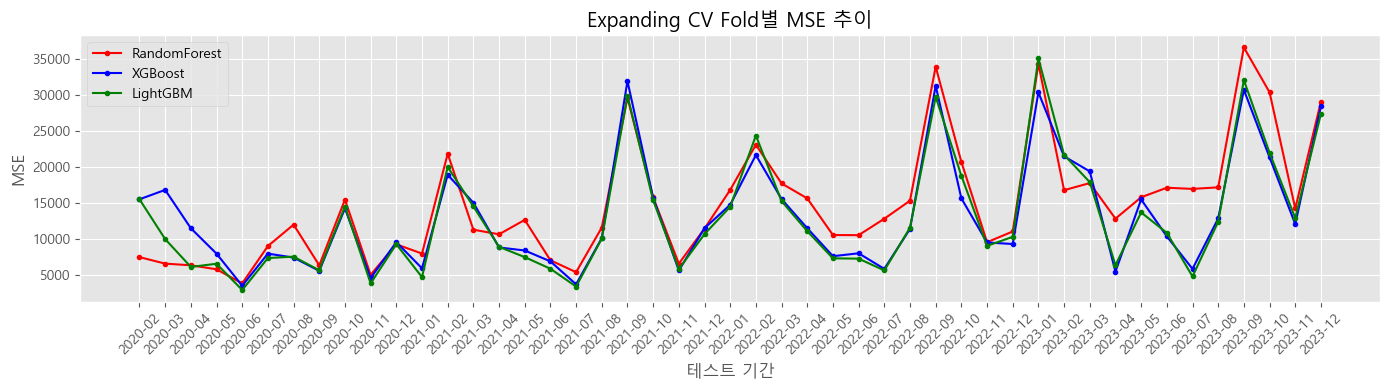

In [9]:
# 4-3. CV 결과 요약
print('[ CV 평균 성능 ]')
print(f'{"모델":<14} {"MSE":>10}  {"MAE":>8}')
print('─' * 36)
print(f'{"RandomForest":<14} {df_cv["mse_rf"].mean():>10.2f}  {df_cv["mae_rf"].mean():>8.2f}')
print(f'{"XGBoost":<14} {df_cv["mse_xgb"].mean():>10.2f}  {df_cv["mae_xgb"].mean():>8.2f}')
print(f'{"LightGBM":<14} {df_cv["mse_lgbm"].mean():>10.2f}  {df_cv["mae_lgbm"].mean():>8.2f}')

# Fold별 MSE 추이 시각화
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_cv["test_period"], df_cv["mse_rf"],   label="RandomForest", color="red",   marker="o", markersize=3)
ax.plot(df_cv["test_period"], df_cv["mse_xgb"],  label="XGBoost",      color="blue",  marker="o", markersize=3)
ax.plot(df_cv["test_period"], df_cv["mse_lgbm"], label="LightGBM",     color="green", marker="o", markersize=3)
ax.set_xlabel("테스트 기간")
ax.set_ylabel("MSE")
ax.set_title("Expanding CV Fold별 MSE 추이")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/fig5.png", dpi=150, bbox_inches="tight")
plt.show()

best_model = model_lgbm


### 5.1. 타겟 기간 예측 (2024년 1월)

2024년 1월 매출 데이터를 타겟으로 설정하고, Recency Weighting + 선택된 하이퍼파라미터로 학습한 세 모델의 성능을 비교하였다.

**[ CV vs Test 성능 비교 ]**

|               | CV MSE    | CV MAE | Test MSE  | Test MAE |
|---------------|----------:|-------:|----------:|---------:|
| RandomForest  | 14,841    | 79.69  | 21,379    | **82.26** |
| XGBoost       | 13,294    | 74.79  | 19,514    | 88.57    |
| LightGBM      | **12,972**| **72.99**| **17,749** | 89.99 |

- **CV와 테스트 모두 LightGBM이 MSE 기준 최우수**를 기록했다.
- **MAE 기준으로는 RF가 테스트에서 가장 낮다**(82.26). 단, 누적 오차율은 LGBM(-0.92%)이 가장 낮다.
- XGBoost는 중간 성능을 유지한다.

In [10]:
# %% 5-1. Model Evaluation
test_period = df_test['date'].between('2024/01/01', '2024/01/31')

x_range = np.arange(1, len(df_test[test_period]) + 1)
X_test = df_test[test_period][ind_vars]
y_test = df_test[test_period][dep_var]

y_pred_rf   = model_rf.predict(X_test)
y_pred_xgb  = model_xgb.predict(X_test)
y_pred_lgbm = model_lgbm.predict(X_test)

test_mse_rf   = mean_squared_error(y_test, y_pred_rf)
test_mse_xgb  = mean_squared_error(y_test, y_pred_xgb)
test_mse_lgbm = mean_squared_error(y_test, y_pred_lgbm)
test_mae_rf   = mean_absolute_error(y_test, y_pred_rf)
test_mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
test_mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)

print('[ 테스트 성능 (2024-01) ]')
print(f'{"모델":<14} {"MSE":>10}  {"MAE":>8}')
print('─' * 36)
print(f'{"RandomForest":<14} {test_mse_rf:>10.2f}  {test_mae_rf:>8.2f}')
print(f'{"XGBoost":<14} {test_mse_xgb:>10.2f}  {test_mae_xgb:>8.2f}')
print(f'{"LightGBM":<14} {test_mse_lgbm:>10.2f}  {test_mae_lgbm:>8.2f}')


[ 테스트 성능 (2024-01) ]
모델                    MSE       MAE
────────────────────────────────────
RandomForest     21378.71     82.26
XGBoost          19513.92     88.57
LightGBM         17748.83     89.99


### 비즈니스 관점에서의 선택

비즈니스 관점에서는 이해할 수 있는 지표가 중요할 때가 있다. 따라서 MSE, MAPE, MAE 대신 누적 예측오차를 구해 각 모형을 비교하였다. 누적 예측오차는 모형이 몇 억원을 과대/과소 추정했는지 한 번에 설명할 수 있는 지표다.

$ 오차율 = \cfrac{(예측값 - 실제값)}{실제값} \times 100\% $

**LightGBM**이 오차율 -0.92%(실제 대비 249억 과소 추정)로 가장 낮은 오차를 기록했다. 실제 매출 27,100억 원 기준 1% 이내로 월간 목표 관리에 충분히 활용 가능한 수준이다.

> "2023년 이전 데이터(Recency Weighting)를 기반으로 2024년 1월 매출을 LightGBM 모델로 예측"


In [11]:
print(f'''
RandomForest 예측 오차   : {y_pred_rf.sum() - y_test.sum():.2f} 억원
XGBoost 예측 오차        : {y_pred_xgb.sum() - y_test.sum():.2f} 억원
LightGBM 예측 오차       : {y_pred_lgbm.sum() - y_test.sum():.2f} 억원 
''')

print(f'''
실제 매출액              : {y_test.sum():.2f} 억원
RandomForest 예측 매출액 : {y_pred_rf.sum():.2f} 억원
XGBoost 예측 매출액      : {y_pred_xgb.sum():.2f} 억원
LightGBM 예측 매출액     : {y_pred_lgbm.sum():.2f} 억원
''')

print(f'''
RandomForest 예측 오차율 : {100*(y_pred_rf.sum() - y_test.sum())/y_test.sum():.2f} %
XGBoost 예측 오차율      : {100*(y_pred_xgb.sum() - y_test.sum())/y_test.sum():.2f} %
LightGBM 예측 오차율     : {100*(y_pred_lgbm.sum() - y_test.sum())/y_test.sum():.2f} %
''')


RandomForest 예측 오차   : -543.66 억원
XGBoost 예측 오차        : -1724.71 억원
LightGBM 예측 오차       : -248.88 억원 


실제 매출액              : 27100.26 억원
RandomForest 예측 매출액 : 26556.60 억원
XGBoost 예측 매출액      : 25375.55 억원
LightGBM 예측 매출액     : 26851.38 억원


RandomForest 예측 오차율 : -2.01 %
XGBoost 예측 오차율      : -6.36 %
LightGBM 예측 오차율     : -0.92 %



In [12]:
# CV vs Test 종합 비교
summary = pd.DataFrame({
    'CV MSE':   [df_cv['mse_rf'].mean(),  df_cv['mse_xgb'].mean(),  df_cv['mse_lgbm'].mean()],
    'CV MAE':   [df_cv['mae_rf'].mean(),  df_cv['mae_xgb'].mean(),  df_cv['mae_lgbm'].mean()],
    'Test MSE': [test_mse_rf,  test_mse_xgb,  test_mse_lgbm],
    'Test MAE': [test_mae_rf,  test_mae_xgb,  test_mae_lgbm],
}, index=['RandomForest', 'XGBoost', 'LightGBM'])

print('[ CV vs Test 성능 비교 ]')
print(summary.round(2).to_string())
print()
print('* CV: Expanding Window 47 folds 평균  |  Test: 2024-01 (31일)')


[ CV vs Test 성능 비교 ]
                CV MSE  CV MAE  Test MSE  Test MAE
RandomForest  14840.53   79.69  21378.71     82.26
XGBoost       13294.38   74.79  19513.92     88.57
LightGBM      12971.54   72.99  17748.83     89.99

* CV: Expanding Window 47 folds 평균  |  Test: 2024-01 (31일)


### 5.2. 예측 시각화

2024년 1월 매출 데이터를 기준으로 **RandomForest**, **XGBoost**, **LightGBM** 모델의 예측 결과와 실제 매출 데이터를 시각화한 것이다.

- **검정색 실선**은 실제 매출 데이터를 나타낸다.
- **RandomForest**(빨간색 점선), **XGBoost**(파란색 점선), **LightGBM**(녹색 점선) 모두 매출을 비교적 정확하게 예측한다.

**LightGBM**이 MSE 기준으로 가장 낮은 오차를 기록하였으며, 누적 오차율도 -0.92%로 가장 안정적이다.


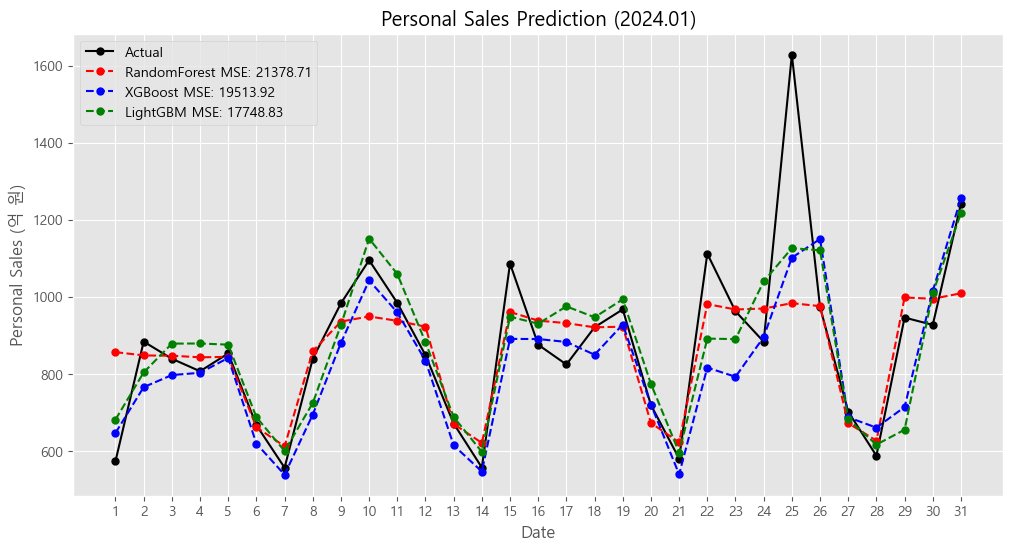

In [13]:
# %% 5-2. Model Visualization
plt.rc('figure', figsize=(12,6))

plt.plot(x_range, y_test, 
         marker='o', markersize=5, label='Actual', color='black')
plt.plot(x_range, y_pred_rf, 
         marker='o', markersize=5, label=f'RandomForest MSE: {mean_squared_error(y_pred_rf, y_test):.2f}', 
         linestyle='--', color='red')
plt.plot(x_range, y_pred_xgb,
            marker='o', markersize=5, label=f'XGBoost MSE: {mean_squared_error(y_pred_xgb, y_test):.2f}', 
            linestyle='--', color='blue')
plt.plot(x_range, y_pred_lgbm,
            marker='o', markersize=5, label=f'LightGBM MSE: {mean_squared_error(y_pred_lgbm, y_test):.2f}', 
            linestyle='--', color='green')

plt.title('Personal Sales Prediction (2024.01)')
plt.xlabel('Date')
plt.ylabel('Personal Sales (억 원)')
plt.xticks(x_range, df_test[test_period]['date'].dt.day)
plt.legend()
plt.savefig("images/fig1.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.3. 특성 중요도 분석

**LightGBM 모델**의 split count 기준 특성 중요도를 시각화하였다.

| 변수 | split count | 순위 |
|------|------------:|:----:|
| 승인일자 | 5,085 | 1위 |
| 일(day) | 4,150 | 2위 |
| 요일(dayofweek) | 2,033 | 3위 |
| 월(month) | 1,470 | 4위 |
| 연도(year) | 2 | 5위 |

- **승인일자**: 연·월·일을 하나의 정수로 인코딩한 값으로, 시계열 추세와 계절성을 통합적으로 포착하기 때문에 가장 많이 활용된다.
- **일(day)**: 월 중 날짜(급여일·월말 소비 급증 등 월내 패턴)를 반영하여 두 번째로 높은 중요도를 보였다.
- **요일(dayofweek)**: 주간 소비 사이클(평일·주말 패턴)을 포착한다.
- **월(month)**: 계절성을 반영하지만, 승인일자와 일에 이미 담긴 정보가 많아 상대적으로 낮다.
- **연도(year)**: Recency Weighting으로 연도별 학습 가중치가 조정되었기 때문에, 연도 자체는 분기 기준으로 거의 사용되지 않는다.

특성 중요도 결과는 **승인일자·일·요일** 세 변수가 매출 변화의 대부분을 설명하며, 절대적 날짜 정보와 월내·주간 주기성이 예측의 핵심임을 시사한다.

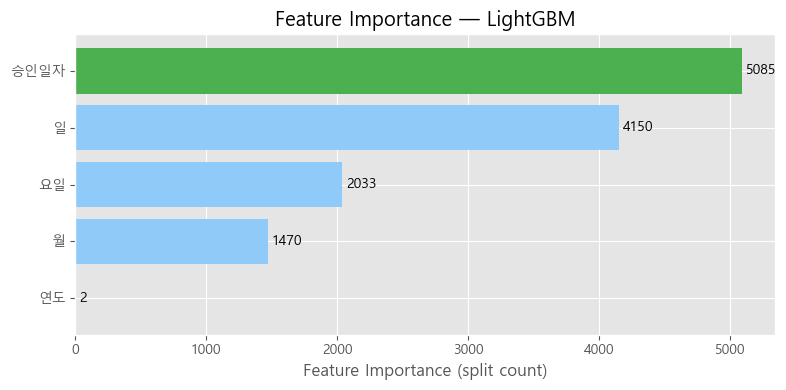

In [14]:
# %% 5-3. Feature Importance (LightGBM)
feature_name_ko = {
    '승인일자': '승인일자',
    'year':     '연도',
    'month':    '월',
    'day':      '일',
    'dayofweek': '요일',
}

df_fi = pd.DataFrame({
    'feature':    ind_vars,
    'importance': model_lgbm.feature_importances_,
}).sort_values('importance', ascending=True)

df_fi['feature_ko'] = df_fi['feature'].map(feature_name_ko)

plt.figure(figsize=(8, 4))
colors = ['#4CAF50' if v == df_fi['importance'].max() else '#90CAF9'
          for v in df_fi['importance']]
bars = plt.barh(df_fi['feature_ko'], df_fi['importance'], color=colors)
plt.bar_label(bars, fmt='%.0f', padding=3)
plt.xlabel('Feature Importance (split count)')
plt.title('Feature Importance — LightGBM')
plt.tight_layout()
plt.savefig('images/fig6.png', dpi=150, bbox_inches='tight')
plt.show()


# 6. 결론

본 프로젝트에서는 RandomForest, XGBoost, LightGBM 세 가지 모델에 **Recency Weighting**(2020=0.1, 2021=0.2, 2022=0.3, 2023=0.4)과 선택된 하이퍼파라미터(RF-A / XGB-A / LGBM-default)를 적용하여 2024년 1월 신용카드 매출을 예측하였다.

**하이퍼파라미터 설정 (max_depth=5 고정):**
- RF: `max_features='sqrt'`, `min_samples_leaf=3`
- XGB: `colsample_bytree=0.8`, `min_child_weight=3`, `reg_alpha=0.05`
- LGBM: `num_leaves=31`(기본값), `colsample_bytree=1.0`(기본값), `min_child_samples=20`(기본값), `reg_alpha=0`

**CV vs Test 성능 비교:**

|               | CV MSE    | CV MAE  | Test MSE  | Test MAE | Test 오차율 |
|---------------|----------:|--------:|----------:|---------:|-----------:|
| RandomForest  | 14,841    | 79.69   | 21,379    | **82.26** | -2.01%    |
| XGBoost       | 13,294    | 74.79   | 19,514    | 88.57    | -6.36%    |
| LightGBM      | **12,972**| **72.99**| **17,749** | 89.99   | **-0.92%** |

**핵심 인사이트:**
- **LightGBM을 최종 모델로 선택**: CV MSE 최소, Test MSE 최소, 누적 오차율 최소(-0.92%)로 세 지표 모두에서 최우수.
- **MAE 기준으로는 RF가 테스트에서 최우수(82.26)이나**, MSE와 누적 오차율 두 지표에서 LGBM이 앞서므로 LGBM을 채택한다.
- 실제 매출 27,100억 원 대비 249억 원(0.92%) 과소 추정으로 월간 목표 관리에 활용 가능한 수준이다.

# 6. 결론

본 프로젝트에서는 RandomForest, XGBoost, LightGBM 세 가지 모델을 활용하여 2024년 1월의 신용카드 매출을 예측하였다. Time Window Expanding Cross Validation으로 모델 성능을 평가하고, **Recency Weighting**(연도별 가중치 2020=0.1, 2021=0.2, 2022=0.3, 2023=0.4)을 적용해 전체 훈련 데이터(2020~2023)로 최종 모델을 학습하였다.

**CV 평균 MSE 순위 (낮을수록 우수):**
- **LightGBM**: 12,972 (1위)
- **XGBoost**: 13,294 (2위)
- **RandomForest**: 14,841 (3위)

**최종 테스트 MSE 순위 (2024년 1월, 낮을수록 우수):**
- **LightGBM**: 17,749 — 예측 매출 26,851억원, 오차율 **-0.92%** (1위)
- **XGBoost**: 19,514 — 예측 매출 25,376억원, 오차율 -6.36% (2위)
- **RandomForest**: 21,379 — 예측 매출 26,557억원, 오차율 -2.01% (3위)

CV와 테스트 모두 LightGBM이 MSE 기준 최우수를 기록하였다. 실제 매출 27,100억 원 대비 249억 원(0.92%) 과소 추정으로 월간 목표 관리에 활용 가능한 수준을 달성했다.

# 7. References

In [15]:
import sklearn as sk
import xgboost as xgb
import lightgbm as lgb

print(f'numpy version: {np.__version__}')
print(f'pandas version: {pd.__version__}')
print(f'seaborn version: {sns.__version__}')
print(f'matplotlib version: {mpl.__version__}')
print(f'scikit-learn version: {sk.__version__}')
print(f'xgboost version: {xgb.__version__}')
print(f'lightgbm version: {lgb.__version__}')

numpy version: 2.3.1
pandas version: 2.3.1
seaborn version: 0.13.2
matplotlib version: 3.10.0
scikit-learn version: 1.6.1
xgboost version: 3.0.1
lightgbm version: 4.6.0
